In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_stata('ECON0019_empirical_project_2026.dta')

# MODEL 1
# Define log(viorate)
df['log_viorate'] = np.log(df['viorate'])

# Define independent and dependent variables
X = df[['shallcarry']]
X = sm.add_constant(X)
y = df['log_viorate']

# Regress y on X:
model = sm.OLS(y, X).fit()
print("Model 1")
print(model.summary())

Model 1
                            OLS Regression Results                            
Dep. Variable:            log_viorate   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     111.1
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           7.09e-25
Time:                        17:26:24   Log-Likelihood:                -1097.7
No. Observations:                1173   AIC:                             2199.
Df Residuals:                    1171   BIC:                             2209.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1349      0.021    296.130 

In [6]:
# MODEL II
# Define independent and dependent variables
X = df[['shallcarry','popdens','avginc','popul','pctmale','pctwhite','pctblack']]
X = sm.add_constant(X)
y = df['log_viorate']

# Regress y on X:
model = sm.OLS(y, X).fit()
print("Model 2")
print(model.summary())

Model 2
                            OLS Regression Results                            
Dep. Variable:            log_viorate   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     153.3
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          2.68e-160
Time:                        17:27:56   Log-Likelihood:                -767.88
No. Observations:                1173   AIC:                             1552.
Df Residuals:                    1165   BIC:                             1592.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1959      0.587      7.147 

In [23]:
# Question 3
# Create lag variable
df = df.sort_values(['state', 'year'])
df['shallcarry_lag'] = df.groupby('state')['shallcarry'].shift(1)
df_lag = df.dropna(subset=['shallcarry_lag']).copy()

print(f"Sample size with lag: {len(df_lag)} observations")
print(f"Years covered: {df_lag['year'].min()} to {df_lag['year'].max()}")
print(f"(First year dropped for each state due to inapplicable first lag)")

# MODEL II with First Lag included
X = df_lag[['shallcarry','shallcarry_lag','popdens','avginc','popul','pctmale','pctwhite','pctblack']]
X = sm.add_constant(X1) 
y = df_lag['log_viorate']

# Regress y on X:
model3 = sm.OLS(y, X).fit()
print("\nModel 2 with first lag of shallcarry\n")
print(model3.summary())

Sample size with lag: 1122 observations
Years covered: 78 to 99
(First year dropped for each state due to inapplicable first lag)

Model 2 with first lag of shallcarry

                            OLS Regression Results                            
Dep. Variable:            log_viorate   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     129.6
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          2.85e-153
Time:                        18:04:22   Log-Likelihood:                -734.82
No. Observations:                1122   AIC:                             1488.
Df Residuals:                    1113   BIC:                             1533.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err     

In [54]:
# Question 4: Fixed Effects Model

from linearmodels.panel import PanelOLS
import statsmodels.api as sm
import pandas as pd

y = df['log_viorate']
exog = sm.add_constant(df[['shallcarry', 'popdens', 'avginc', 'popul', 
                           'pctmale', 'pctwhite', 'pctblack']])

# Estimate fixed effects model with clustered standard errors
# State characteristics are autocorrelated, so use clustered standard errors that allow for correlation within clusters, but assume independence between clusters
model4 = PanelOLS(dependent, exog, entity_effects=True).fit(
    cov_type='clustered',
    cluster_entity=True
)

print(model4)
print(f"\nshallcarry coefficient: {model4.params['shallcarry']:.6f}")
print(f"Clustered SE: {model4.std_errors['shallcarry']:.6f}")
print(f"p-value: {model4.pvalues['shallcarry']:.6f}")

                          PanelOLS Estimation Summary                           
Dep. Variable:            log_viorate   R-squared:                        0.2174
Estimator:                   PanelOLS   R-squared (Between):             -0.0528
No. Observations:                1173   R-squared (Within):               0.2174
Date:                Sun, Mar 08 2026   R-squared (Overall):             -0.0325
Time:                        20:45:45   Log-likelihood                    509.88
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      44.245
Entities:                          51   P-value                           0.0000
Avg Obs:                       23.000   Distribution:                  F(7,1115)
Min Obs:                       23.000                                           
Max Obs:                       23.000   F-statistic (robust):             39.760
                            

In [56]:
# Question 5: Controlling for time and state fixed effects

from linearmodels.panel import PanelOLS
import statsmodels.api as sm
import pandas as pd

y = df['log_viorate']
exog = sm.add_constant(df[['shallcarry', 'popdens', 'avginc', 'popul', 
                           'pctmale', 'pctwhite', 'pctblack']])

# Estimate fixed effects model with clustered standard errors for same reason as Question 4
model5 = PanelOLS(dependent, exog, entity_effects=True, time_effects=True).fit(
    cov_type='clustered',
    cluster_entity=True
)

print(model5)
print(f"\nshallcarry coefficient: {model5.params['shallcarry']:.4f}")
print(f"Clustered SE: {model5.std_errors['shallcarry']:.4f}")
print(f"p-value: {model5.pvalues['shallcarry']:.4f}")


                          PanelOLS Estimation Summary                           
Dep. Variable:            log_viorate   R-squared:                        0.0557
Estimator:                   PanelOLS   R-squared (Between):             -0.2622
No. Observations:                1173   R-squared (Within):              -0.9511
Date:                Sun, Mar 08 2026   R-squared (Overall):             -0.3141
Time:                        20:47:37   Log-likelihood                    683.20
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      9.2169
Entities:                          51   P-value                           0.0000
Avg Obs:                       23.000   Distribution:                  F(7,1093)
Min Obs:                       23.000                                           
Max Obs:                       23.000   F-statistic (robust):             2.9756
                            

In [60]:
# Calculating robust F test (Wald) if time dummies are jointly significant

from linearmodels.panel import compare

print(compare({'Entity Effects': model4, 'Entity + Time Effects': model5}))
print("\n")
print(model5.summary)

                       Model Comparison                      
                         Entity Effects Entity + Time Effects
-------------------------------------------------------------
Dep. Variable               log_viorate           log_viorate
Estimator                      PanelOLS              PanelOLS
No. Observations                   1173                  1173
Cov. Est.                     Clustered             Clustered
R-squared                        0.2174                0.0557
R-Squared (Within)               0.2174               -0.9511
R-Squared (Between)             -0.0528               -0.2622
R-Squared (Overall)             -0.0325               -0.3141
F-statistic                      44.245                9.2169
P-value (F-stat)                 0.0000                0.0000
=====================     =============         =============
const                            3.8555                4.2716
                               (4.9945)              (3.1919)
shallcar

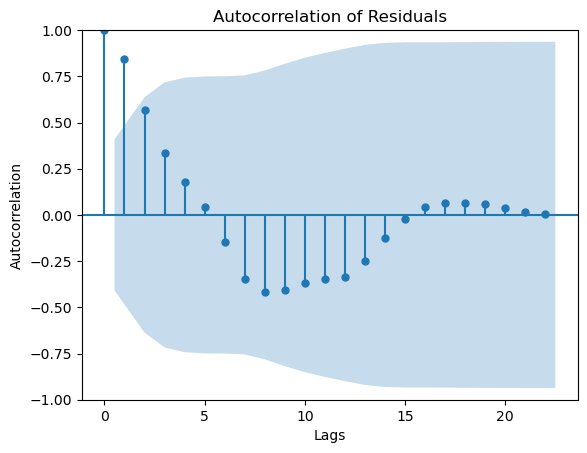

In [73]:
# Question 6: Residual Plot for Alabama

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

residuals = model5.resids
alabama_residuals = residuals[df.index.get_level_values('state') == 1]

# Total Lags is 1999-1977 = 22
plot_acf(alabama_residuals, lags=22)
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation of Residuals')
plt.show()

In [79]:
# Question 7 Fixed Effects for log_robrate and log_murrate

# log_robrate
df['log_robrate'] = np.log(df['robrate'])
y = df['log_robrate']
exog = sm.add_constant(df[['shallcarry', 'popdens', 'avginc', 'popul', 
                           'pctmale', 'pctwhite', 'pctblack']])
model7robrate = PanelOLS(dependent, exog, entity_effects=True).fit(
    cov_type='clustered',
    cluster_entity=True
)

print(model7robrate)

                          PanelOLS Estimation Summary                           
Dep. Variable:            log_viorate   R-squared:                        0.2174
Estimator:                   PanelOLS   R-squared (Between):             -0.0528
No. Observations:                1173   R-squared (Within):               0.2174
Date:                Sun, Mar 08 2026   R-squared (Overall):             -0.0325
Time:                        21:07:20   Log-likelihood                    509.88
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      44.245
Entities:                          51   P-value                           0.0000
Avg Obs:                       23.000   Distribution:                  F(7,1115)
Min Obs:                       23.000                                           
Max Obs:                       23.000   F-statistic (robust):             39.760
                            

In [78]:
# log_murrate
df['log_murrate'] = np.log(df['murrate'])
y = df['log_murrate']
exog = sm.add_constant(df[['shallcarry', 'popdens', 'avginc', 'popul', 
                           'pctmale', 'pctwhite', 'pctblack']])
model7murrate = PanelOLS(dependent, exog, entity_effects=True).fit(
    cov_type='clustered',
    cluster_entity=True
)

print(model7murrate)

                          PanelOLS Estimation Summary                           
Dep. Variable:            log_viorate   R-squared:                        0.2174
Estimator:                   PanelOLS   R-squared (Between):             -0.0528
No. Observations:                1173   R-squared (Within):               0.2174
Date:                Sun, Mar 08 2026   R-squared (Overall):             -0.0325
Time:                        21:06:43   Log-likelihood                    509.88
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      44.245
Entities:                          51   P-value                           0.0000
Avg Obs:                       23.000   Distribution:                  F(7,1115)
Min Obs:                       23.000                                           
Max Obs:                       23.000   F-statistic (robust):             39.760
                            